In [9]:
import pandas as pd, numpy as np, warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,
                             precision_recall_fscore_support, RocCurveDisplay,
                             PrecisionRecallDisplay, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import shap, joblib

In [ ]:
df = pd.read_csv("paysim.csv")
df = df.drop(columns=["bank_txn_id", "date"])          
y = df["target_anomaly"].astype(int)
X = df.drop(columns=["target_anomaly"])
print("Anomaly rate:", round(y.mean(), 3))

Anomaly rate: 0.05


In [11]:
cat = ["txn_type", "direction", "channel"]
num = [c for c in X.columns if c not in cat]
pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat),
                         ("num", "passthrough", num)])
def P(m): return Pipeline([("pre", pre), ("m", m)])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
spw = (y_train == 0).sum() / (y_train == 1).sum()      
models = {
 "LogisticRegression": P(LogisticRegression(max_iter=1000, class_weight="balanced")),
 "DecisionTree":       P(DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42)),
 "RandomForest":       P(RandomForestClassifier(n_estimators=200, class_weight="balanced",
                          random_state=42, n_jobs=-1)),
 "XGBoost":            P(XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                          subsample=0.9, scale_pos_weight=spw, eval_metric="logloss", random_state=42)),
}
print("=== Model comparison (anomaly class) ===")
aucs = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    proba = m.predict_proba(X_test)[:, 1]; pred = m.predict(X_test)
    aucs[name] = roc_auc_score(y_test, proba)
    pr, rc, f1, _ = precision_recall_fscore_support(y_test, pred, average="binary", zero_division=0)
    print(f"  {name:18s} AUC {aucs[name]:.3f} | Prec {pr:.2f} Rec {rc:.2f} F1 {f1:.2f}")
best_name = max(aucs, key=aucs.get)
print("Best model:", best_name)
model = models[best_name]; model.fit(X_train, y_train)

=== Model comparison (anomaly class) ===
  LogisticRegression AUC 0.904 | Prec 0.19 Rec 0.81 F1 0.31
  DecisionTree       AUC 0.913 | Prec 0.23 Rec 0.79 F1 0.35
  RandomForest       AUC 0.892 | Prec 0.38 Rec 0.43 F1 0.40
  XGBoost            AUC 0.914 | Prec 0.23 Rec 0.78 F1 0.36
Best model: XGBoost


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('m', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['txn_type','amount_abs_rs','direction',...,'day_of_month', 'created_offline','amount_zscore']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'

In [13]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print("\nROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print("PR-AUC :", round(average_precision_score(y_test, y_proba), 3))
print(classification_report(y_test, y_pred, target_names=["normal", "anomaly"]))


ROC-AUC: 0.914
PR-AUC : 0.517
              precision    recall  f1-score   support

      normal       0.99      0.86      0.92     31209
     anomaly       0.23      0.78      0.36      1643

    accuracy                           0.86     32852
   macro avg       0.61      0.82      0.64     32852
weighted avg       0.95      0.86      0.89     32852



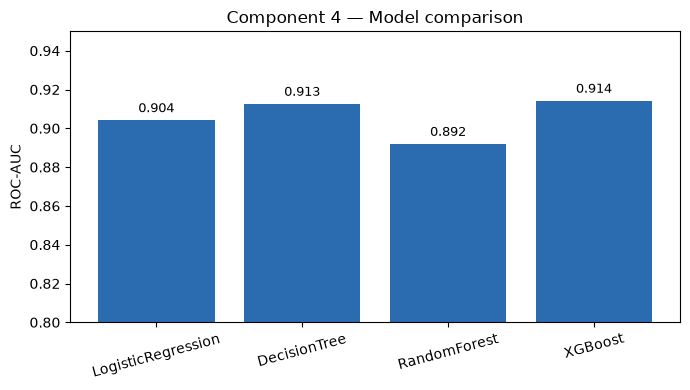

In [14]:
plt.figure(figsize=(7,4)); bars = plt.bar(aucs.keys(), aucs.values(), color="#2b6cb0")
for b, v in zip(bars, aucs.values()): plt.text(b.get_x()+b.get_width()/2, v+0.004, f"{v:.3f}", ha="center", fontsize=9)
plt.ylim(0.8, 0.95); plt.ylabel("ROC-AUC"); plt.title("Component 4 — Model comparison")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

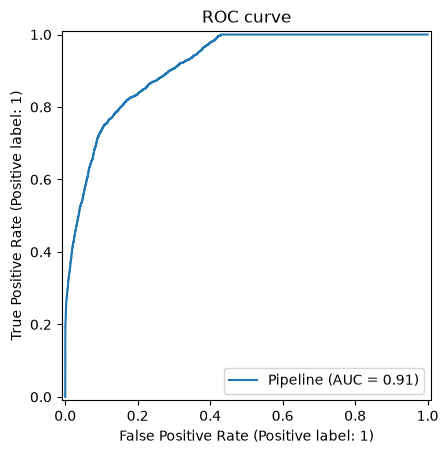

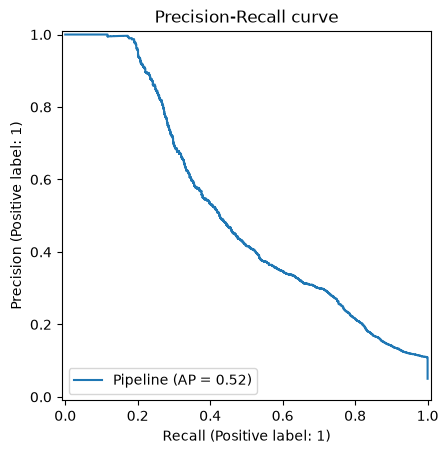

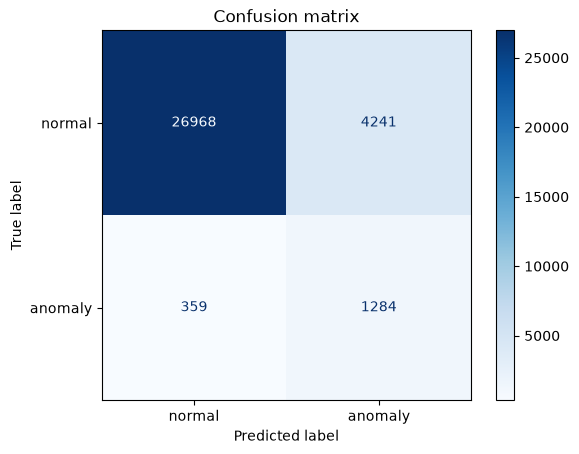

In [15]:
RocCurveDisplay.from_estimator(model, X_test, y_test); plt.title("ROC curve"); plt.show()
PrecisionRecallDisplay.from_estimator(model, X_test, y_test); plt.title("Precision-Recall curve"); plt.show()
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test,
    display_labels=["normal", "anomaly"], cmap="Blues"); plt.title("Confusion matrix"); plt.show()

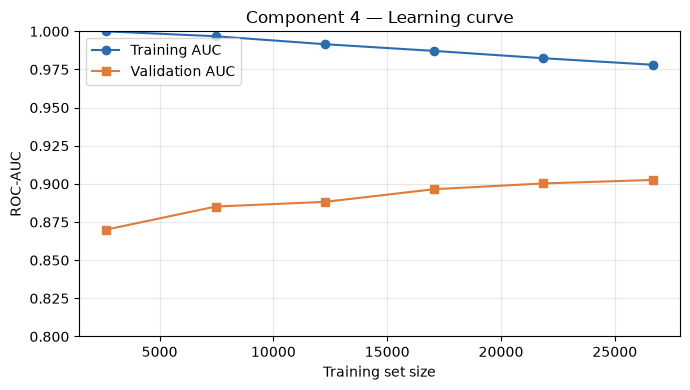

Training AUC: 0.978 | Validation AUC: 0.903


In [16]:
idx = np.random.RandomState(0).choice(len(X), 40000, replace=False)
sizes, tr, val = learning_curve(model, X.iloc[idx], y.iloc[idx],
    cv=StratifiedKFold(3, shuffle=True, random_state=0), scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1)
plt.figure(figsize=(7,4))
plt.plot(sizes, tr.mean(1),  "o-", label="Training AUC",   color="#2b6cb0")
plt.plot(sizes, val.mean(1), "s-", label="Validation AUC", color="#e07b39")
plt.xlabel("Training set size"); plt.ylabel("ROC-AUC"); plt.ylim(0.8, 1.0)
plt.title("Component 4 — Learning curve"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Training AUC:", round(tr.mean(1)[-1], 3), "| Validation AUC:", round(val.mean(1)[-1], 3))

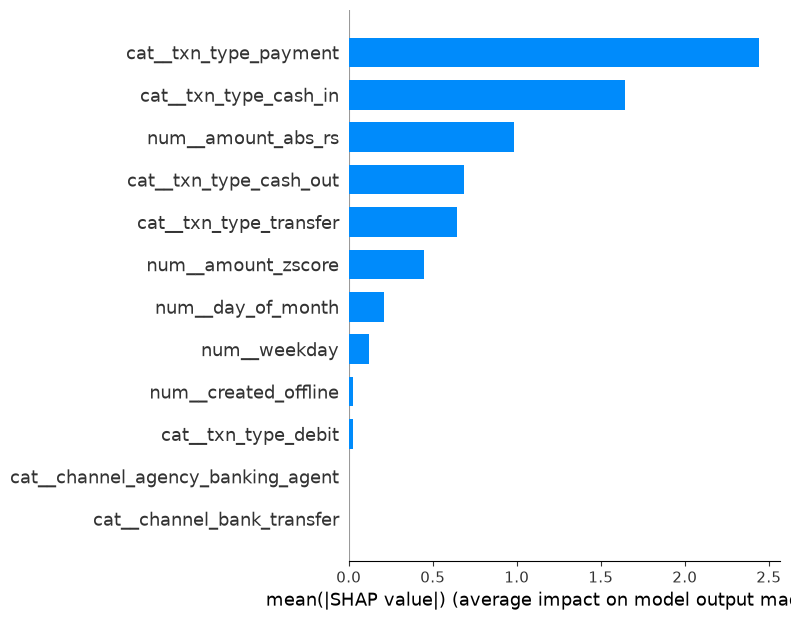

In [17]:
Xt = model.named_steps["pre"].transform(X_test[:2000])
Xt = Xt.toarray() if hasattr(Xt, "toarray") else np.asarray(Xt)
Xt = Xt.astype(float)
feat_names = model.named_steps["pre"].get_feature_names_out()
explainer = shap.TreeExplainer(model.named_steps["m"])
shap_values = explainer.shap_values(Xt)
shap.summary_plot(shap_values, features=Xt, feature_names=feat_names, plot_type="bar", max_display=12)

In [18]:
joblib.dump(model, "component4_banking_anomaly_model.pkl")
print("Saved best model:", best_name)

Saved best model: XGBoost
